# Exemplo 1A — 25 contrapartes e um setor

## O que este notebook faz

Este é o primeiro dos exemplos oficiais: a carteira da Tabela 8 do manual, com 25 contrapartes, reproduzida contra a aba `Example1A` da planilha do Credit Suisse.

O objetivo não é ilustrar — é **provar**. As células abaixo contêm asserções que comparam os resultados com os valores publicados em 1997. Se a matemática regredir, a célula falha.

## A carteira

Recuperação zero (o manual avisa na seção B2 que as exposições da Tabela 8 já são líquidas), horizonte de um ano e um único fator de economia geral. Todas as contrapartes compartilham esse fator, o que faz desta a carteira **mais concentrada** dos exemplos: não há diversificação entre setores para amortecer a cauda. Os notebooks 07 e 08 mostram quanto isso custa.

As taxas de default são deliberadamente altas — de 1,5% a 30% ao ano — para tornar os efeitos visíveis numa carteira de apenas 25 nomes. O próprio manual chama esses níveis de irreais.

## Duas convenções que aparecem aqui

**Quantil.** A comparação com o XLS usa a interpolação linear da planilha; as métricas econômicas usam o quantil discreto, que é o VaR matemático. Os dois diferem por menos de uma unidade $L$ e ambos aparecem na tabela abaixo.

**Contribuição de risco.** A equação 121 do manual não especifica se a PD a usar é a bruta do rating ou a compensada pelo banding. As duas leituras produzem alocações diferentes, e ambas estão implementadas. Isso é explorado na seção de contribuições.

In [1]:
# Imports, dados oficiais e unidade usada pela planilha.
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from creditriskplus import CreditRiskPlus, data

portfolio = data.create_example_1a_portfolio()
unit_size = float(np.ceil(portfolio.exposure.max()/100))
model = CreditRiskPlus(unit_size=unit_size, max_loss_units=int(np.ceil(250_000_000/unit_size)))
model.set_portfolio(portfolio, sector_columns=['sector_weight_general_economy'])
model.calculate_loss_distribution()
result = model.result
display(portfolio)

,obligor_id,exposure,rating,mean_default_rate,std_default_rate,sector_weight_general_economy
0,1,358475,H,0.300,0.1500,1.0
1,2,1089819,H,0.300,0.1500,1.0
2,3,1799710,F,0.100,0.0500,1.0
3,4,1933116,G,0.150,0.0750,1.0
4,5,2317327,G,0.150,0.0750,1.0
5,6,2410929,G,0.150,0.0750,1.0
6,7,2652184,H,0.300,0.1500,1.0
7,8,2957685,G,0.150,0.0750,1.0
8,9,3137989,D,0.050,0.0250,1.0
9,10,3204044,D,0.050,0.0250,1.0


In [2]:
# Regressão contra os valores publicados. Os três primeiros vêm da planilha;
# o desvio padrão está impresso na seção B3.4 do manual.
reference_el, reference_var99, reference_sigma = 14_221_863.0, 55_311_503.0, 12_668_742.0
reported = pd.Series({
    'EL': result.expected_loss, 'Sigma analítico': model.loss_std,
    'VaR99 discreto': result.quantile(.99),
    'VaR99 interpolado como XLS': result.quantile(.99, interpolate=True),
    'EC99 discreto': result.quantile(.99)-result.expected_loss,
    'Massa truncada': result.tail_mass_upper_bound,
})
display(reported.to_frame('valor'))

assert abs(result.expected_loss-reference_el) < 1
assert abs(result.quantile(.99, interpolate=True)-reference_var99) < 1
assert abs(model.loss_std-reference_sigma) < 1
assert result.tail_mass_upper_bound < 1e-10

# Os oito percentis publicados, não apenas o de 99%. Bater em todos eles é o que
# demonstra que a distribuição inteira — e não um ponto isolado — está correta.
published = {50: 11_089_455, 75: 20_498_062, 95: 38_908_486, 97.5: 46_152_128,
             99: 55_311_503, 99.5: 62_033_181, 99.75: 68_612_540, 99.9: 77_133_478}
percentis = pd.DataFrame([
    {'Percentil': p,
     'Modelo (interpolado)': result.quantile(p/100, interpolate=True),
     'XLS oficial': v,
     'Modelo (discreto)': result.quantile(p/100)}
    for p, v in published.items()
])
display(percentis.style.format({'Modelo (interpolado)': '{:,.0f}', 'XLS oficial': '{:,.0f}',
                                'Modelo (discreto)': '{:,.0f}'}))
for p, v in published.items():
    assert abs(result.quantile(p/100, interpolate=True)-v) < 1, p
print("Os oito percentis publicados são reproduzidos com diferença inferior a 1 unidade monetária.")

,valor
EL,1.422186e+07
Sigma analítico,1.266874e+07
VaR99 discreto,5.545459e+07
VaR99 interpolado como XLS,5.531150e+07
EC99 discreto,4.123272e+07
Massa truncada,1.053824e-12


,Percentil,Modelo (interpolado),XLS oficial,Modelo (discreto)
0,50.000000,"11,089,455","11,089,455","11,131,395"
1,75.000000,"20,498,062","20,498,062","20,643,678"
2,95.000000,"38,908,486","38,908,486","39,061,077"
3,97.500000,"46,152,128","46,152,128","46,347,081"
4,99.000000,"55,311,503","55,311,503","55,454,586"
5,99.500000,"62,033,181","62,033,181","62,133,423"
6,99.750000,"68,612,540","68,612,540","68,812,260"
7,99.900000,"77,133,478","77,133,478","77,312,598"


Os oito percentis publicados são reproduzidos com diferença inferior a 1 unidade monetária.


## Contribuições de risco

### O que a pergunta significa

A distribuição diz quanto capital a carteira exige. A contribuição de risco responde à pergunta seguinte: **de quem é esse capital?**

É tentador responder "de cada um, na proporção da sua perda esperada". Está errado, e o erro é grande. A perda esperada é aditiva, mas o risco não: um cliente grande num setor concentrado agrava a cauda muito mais do que sua EL sugere. A contribuição mede exatamente esse excedente.

### Como o manual resolve

A contribuição ao desvio padrão é uma derivada — quanto $\sigma$ da carteira muda se a exposição de $A$ aumentar marginalmente:

$$RC_A = \frac{\nu_A \mu_A}{\sigma}\left( \nu_A + \sum_k \left(\frac{\sigma_k}{\mu_k}\right)^2 \varepsilon_k \theta_{Ak} \right)$$

O primeiro termo $\nu_A$ é o risco individual; o segundo é o quanto $A$ participa do risco sistemático compartilhado. Pela equação 123, essas contribuições **somam exatamente $\sigma$** — é uma alocação de Euler, não uma heurística.

A contribuição ao VaR usa a aproximação aditiva da equação 102:

$$\widehat{RC}_A=EL_A+\xi\, RC_A, \qquad \xi=\frac{VaR-EL}{\sigma}$$

### A armadilha

$\widehat{RC}_A$ **não** é a redução de VaR que se obteria removendo a contraparte $A$. Contribuições são derivadas locais; remoções são efeitos finitos. O notebook 05 mede a diferença nos números do próprio manual.

### As duas convenções

A equação 121 escreve $\mu_A$, "o número esperado de defaults de $A$", sem dizer se é a PD bruta do rating ou a PD compensada pelo banding ($\varepsilon_A/\nu_A$).

- `convention="manual"` (padrão) usa a compensada. É a única consistente com a fórmula de variância da equação 118, e por isso soma a $\sigma$ sem nenhuma correção.
- `convention="spreadsheet"` usa a PD bruta e reescala o vetor para somar a $\sigma$. É o que a planilha de 1997 fez, e reproduz a coluna publicada.

A diferença por contraparte chega a 5%, sempre concentrada nas exposições que mais foram arredondadas para cima. A célula seguinte mostra as duas lado a lado contra os valores oficiais.

In [3]:
# Calcula as duas convenções e valida a aditividade prevista no manual.
rc = model.calculate_risk_contributions(percentile=99)
rc_xls = model.calculate_risk_contributions(percentile=99, convention="spreadsheet")

# Equação 123: a decomposição do manual fecha exatamente em sigma, sem rescala.
assert abs(rc.risk_contribution_std.sum()/model.loss_std-1) < 1e-12
assert abs(rc.risk_contribution_99pct.sum()/result.quantile(.99)-1) < 1e-12

rc['rc99_pct'] = 100*rc.risk_contribution_99pct/rc.risk_contribution_99pct.sum()
display(rc.sort_values('risk_contribution_99pct', ascending=False).head(10))

# Coluna K da aba Example1A (Tabela 10 do manual): a alocação publicada em 1997.
oficial = np.array([228711, 764758, 426743, 716735, 896874, 910914, 2163988, 1199910,
                    434047, 437350, 225356, 756325, 794754, 4773594, 1602530, 1330448,
                    892720, 560564, 1477654, 593559, 6850969, 7110748, 487938,
                    9056197, 10618120], float)
confronto = pd.DataFrame({
    'contraparte': portfolio.obligor_id,
    'exposição/L': portfolio.exposure/unit_size,
    'XLS oficial': oficial,
    'convenção spreadsheet': rc_xls.risk_contribution_99pct,
    'convenção manual': rc.risk_contribution_99pct,
})
confronto['erro spreadsheet %'] = 100*(confronto['convenção spreadsheet']/oficial-1)
confronto['erro manual %'] = 100*(confronto['convenção manual']/oficial-1)
display(confronto.head(8).style.format({
    'exposição/L': '{:.2f}', 'XLS oficial': '{:,.0f}', 'convenção spreadsheet': '{:,.0f}',
    'convenção manual': '{:,.0f}', 'erro spreadsheet %': '{:+.4f}', 'erro manual %': '{:+.2f}'}))

# A convenção da planilha reproduz a coluna publicada dentro do arredondamento
# dos inteiros impressos; a do manual diverge onde o banding arredondou mais.
assert np.abs(confronto['convenção spreadsheet']/oficial-1).max() < 1e-5
print(f"Erro máximo da convenção spreadsheet: "
      f"{100*np.abs(confronto['convenção spreadsheet']/oficial-1).max():.5f}%")
print(f"Erro máximo da convenção manual     : "
      f"{100*np.abs(confronto['convenção manual']/oficial-1).max():.2f}%  "
      f"(contraparte {confronto.loc[confronto['erro manual %'].abs().idxmax(), 'contraparte']}, "
      f"a mais arredondada da carteira)")

,obligor_id,exposure,rating,expected_loss,risk_contribution_std,risk_contribution_99pct,rc99_pct
24,25,20238895,E,1517917.125,2.850944e+06,1.079683e+07,19.469684
23,24,15410906,F,1541090.600,2.328217e+06,9.118695e+06,16.443537
21,22,6480322,H,1944096.600,1.570517e+06,7.055629e+06,12.723257
20,21,6466533,H,1939959.900,1.536183e+06,6.939748e+06,12.514290
13,14,4928989,H,1478696.700,1.005566e+06,4.751493e+06,8.568261
6,7,2652184,H,795655.200,4.012530e+05,2.101606e+06,3.789779
14,15,5042312,F,504231.200,3.428950e+05,1.620245e+06,2.921752
18,19,5764596,E,432344.700,3.216373e+05,1.479172e+06,2.667357
15,16,5320364,E,399027.300,2.841019e+05,1.323689e+06,2.386978
7,8,2957685,G,443652.750,2.308239e+05,1.194911e+06,2.154756


,contraparte,exposição/L,XLS oficial,convenção spreadsheet,convenção manual,erro spreadsheet %,erro manual %
0,1,1.77,"228,711","228,711","216,958",-0.0001,-5.14
1,2,5.38,"764,758","764,758","727,582",+0.0001,-4.86
2,3,8.89,"426,743","426,743","428,579",-0.0000,+0.43
3,4,9.55,"716,735","716,735","705,599",-0.0001,-1.55
4,5,11.45,"896,874","896,874","881,985",-0.0000,-1.66
5,6,11.91,"910,914","910,914","917,610",-0.0000,+0.74
6,7,13.10,"2,163,988","2,163,988","2,101,606",+0.0000,-2.88
7,8,14.61,"1,199,910","1,199,910","1,194,911",-0.0000,-0.42


Erro máximo da convenção spreadsheet: 0.00021%
Erro máximo da convenção manual     : 5.14%  (contraparte 1, a mais arredondada da carteira)


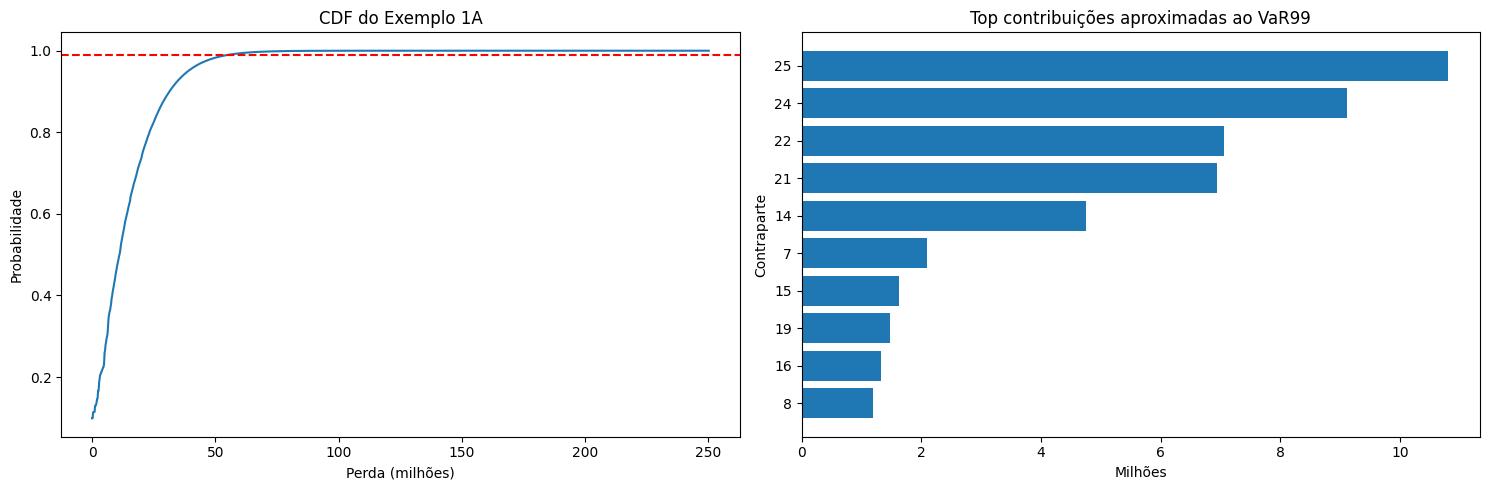

In [4]:
# Distribuição e concentração das contribuições.
losses = np.arange(len(result.pmf))*result.unit_size
top = rc.nlargest(10, 'risk_contribution_99pct').sort_values('risk_contribution_99pct')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(losses/1e6, result.cdf)
axes[0].axhline(.99, color='red', ls='--')
axes[0].set(title='CDF do Exemplo 1A', xlabel='Perda (milhões)', ylabel='Probabilidade')
axes[1].barh(top.obligor_id.astype(str), top.risk_contribution_99pct/1e6)
axes[1].set(title='Top contribuições aproximadas ao VaR99', xlabel='Milhões', ylabel='Contraparte')
plt.tight_layout(); plt.show()

## Leitura dos resultados

**A concentração domina.** As duas maiores exposições respondem por cerca de 36% do capital, e as cinco maiores por cerca de 70%. Compare com a participação delas na perda esperada: bem menor. É a demonstração numérica de que risco e custo esperado se distribuem de formas diferentes.

**O rating não decide sozinho.** A contraparte 25 tem rating E (7,5% de PD) e contribui mais que a 21 e a 22, ambas H (30% de PD). Exposição pesa mais que qualidade quando a diferença de tamanho é grande — aqui, três vezes. Uma política de crédito que olhe só para rating não vê isso.

**O gráfico de CDF** mostra a leitura do VaR: a linha vermelha em 0,99 cruza a curva no ponto que define o capital.

## O que ficou provado

Este exemplo valida simultaneamente:

1. a recursão de um setor, contra os oito percentis publicados;
2. os momentos analíticos, contra o desvio padrão impresso no manual;
3. a alocação de risco do Apêndice A13, contra a Tabela 10 — reproduzida com erro inferior a 0,001% na convenção da planilha.

A suíte `run_tests.py` vai além e confere a **PMF inteira**, ponto a ponto, nos 413 pontos de grade que a planilha publica para este exemplo.

O VaR interpolado é mantido apenas como ponte de reprodutibilidade com o arquivo legado; a API econômica usa o quantil discreto.